# Day 2

Today, we will start using nf-core pipelines to find differentially abundant genes in our dataset. 
We are using data from the following paper: https://www.nature.com/articles/s41593-023-01350-3#Sec10

1. Please take some time to read through the paper and understand their approach, hypotheses and goals.

What was the objective of the study?

The study examines how withdrawal from the opioid oxycodone affects gene expression in the brain's reward system, in mice with and without chronic nerve pain. The goal is to find the mechanisms behind opioid dependence and to test a possible treatment.

What do the conditions mean?

oxy: oxycodone -> The mice received the opioid for a while and then went through withdrawal


sal: saline (salt water). This is the control: the mice got injections without any drug.

What do the genotypes mean?

SNI: spared nerve injury. A surgery that injures a nerve in the leg and causes chronic neuropathic pain.


Sham: fake surgery without nerve injury. This is the pain-free control.


So in summary there are 4 groups: 

Sham-sal: no nerve injury / no pain and no drug (main control)

Sham-oxy: no nerve injury / no  pain and oxycodon exposure, withdrawal

SNI-sal: nerve injury/pain and no drug

SNI-Oxy: nerve injury/pain and oxycodon exposure, withdrawal

Imagine you are the bioinformatician in the group who conducted this study. They hand you the raw files and ask you to analyze them.

What would you do?

1. Run nf-core/rnaseq pipeline (quality control, trimming, alignment to the mouse genome, gene counting)

2. Quality check: Check the MultiQC report, PCA and sample clustering for outliers or batch effects.

3. Differential expression: Run nf-core/differentialabundance pipeline

4. pathway or gene set enrichment analysis to find affected biological processes and key regulators.


Which groups would you compare to each other?

Please also mention which outcome you would expect to see from each comparison.

Sham-Oxy vs Sham-Sal: 
To analyse the effect of oxycodone withdrawal alone.
I  would expect many differentially expressed genes in e.g.  reward and synaptic signalling pathways

SNI-Sal vs Sham-Sal
To analyse the effect of oxycodone withdrawal alone.
I would expect moderate changes in the gene expression of stress-, inflammation- and pain-related genes 

SNI-Oxy vs SNI-Sal
To analyse the effect of withdrawal in mice with chronic pain.
I wold expect changes  that partly overlap with Sham-Oxy, plus genes found only in the pain state

SNI-Oxy vs Sham-Oxy	
To analyse how the chronic pain changes the withdrawal response.
I would ecpect chaneges in genes related to pain, stress and inflammation. Some withdrawal-related genes may respond more strongly or differently when pain is present. 

SNI-Oxy vs Sham-Sal
To analyze the combined effect of pain and withdrawal
I would expect the largest number of changes in genes: genes affected by withdrawal plus genes affected by chronic pain


Your group gave you a very suboptimal excel sheet (conditions_runs_oxy_project.xlsx) to get the information you need for each run they uploaded to the SRA.<br>
So, instead of directly diving into downloading the data and starting the analysis, you first need to sort the lazy table.<br>
Use Python and Pandas to get the table into a more sensible order.<br>
Then, perform some overview analysis and plot the results
1. How many samples do you have per condition?
2. How many samples do you have per genotype?
3. How often do you have each condition per genotype?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("conditions_runs_oxy_project.xlsx")

# one column for condition: "Oxy" where there is an x, otherwise "Sal"
df["condition"] = "Sal"
df.loc[df["Condition: Oxy"] == "x", "condition"] = "Oxy"

# one column for genotype: "SNI" where there is an x, otherwise "Sham"
df["genotype"] = "Sham"
df.loc[df["Genotype: SNI"] == "x", "genotype"] = "SNI"

# keep only the useful columns and sort
samples = df[["Run", "genotype", "condition"]]
samples = samples.sort_values(["genotype", "condition"]).reset_index(drop=True)
samples 

,Run,genotype,condition
0,SRR23195508,SNI,Oxy
1,SRR23195509,SNI,Oxy
2,SRR23195516,SNI,Oxy
3,SRR23195517,SNI,Oxy
4,SRR23195505,SNI,Sal
5,SRR23195510,SNI,Sal
6,SRR23195513,SNI,Sal
7,SRR23195518,SNI,Sal
8,SRR23195506,Sham,Oxy
9,SRR23195511,Sham,Oxy


### 1. How many samples do you have per condition?

condition
Oxy    8
Sal    8
Name: count, dtype: int64


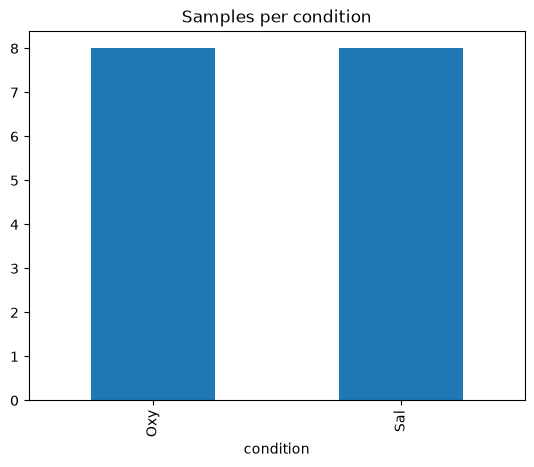

In [9]:
print(samples["condition"].value_counts())

samples["condition"].value_counts().plot(kind="bar", title="Samples per condition")
plt.show()

### 2. How many samples do you have per genotype?

genotype
SNI     8
Sham    8
Name: count, dtype: int64


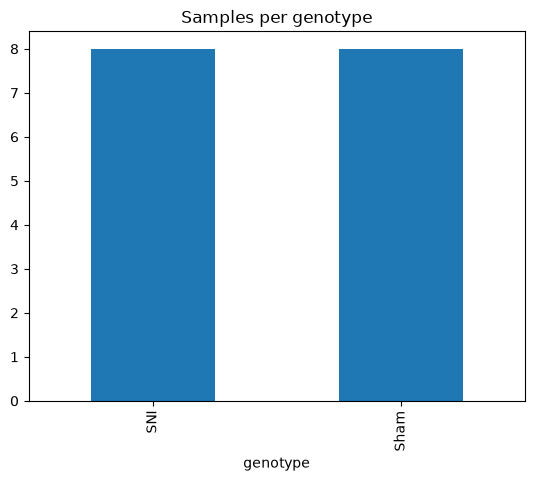

In [8]:
print(samples["genotype"].value_counts())

samples["genotype"].value_counts().plot(kind="bar", title="Samples per genotype")
plt.show()

### 3. How often do you have each condition per genotype?

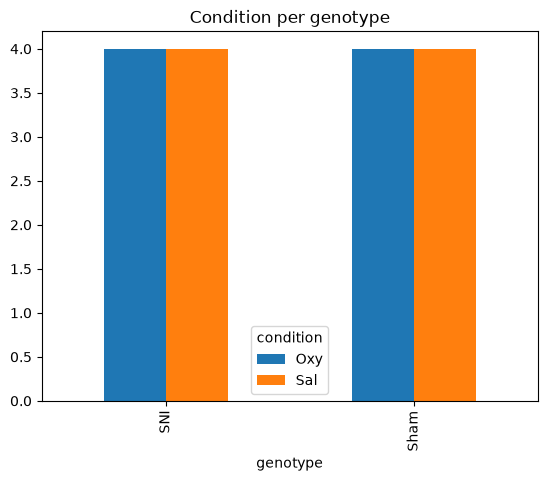

In [7]:
table = pd.crosstab(samples["genotype"], samples["condition"])
table


table.plot(kind="bar", title="Condition per genotype")
plt.show()

They were so kind to also provide you with the information of the number of bases per run, so that you can know how much space the data will take on your Cluster.<br>
Add a new column to your fancy table with this information (base_counts.csv) and sort your dataframe according to this information and the condition.

Then select the 2 smallest runs from your dataset and download them from SRA (maybe an nf-core pipeline can help here?...)

In [10]:
bases = pd.read_csv("base_counts.csv")

# add the "Bases" column by matching the run IDs
samples = samples.merge(bases, on="Run")

# sort by number of bases, then by condition
samples = samples.sort_values(["Bases", "condition"])
samples

,Run,genotype,condition,Bases
2,SRR23195516,SNI,Oxy,6203117700
9,SRR23195511,Sham,Oxy,6456390900
3,SRR23195517,SNI,Oxy,6863840400
4,SRR23195505,SNI,Sal,6922564500
0,SRR23195508,SNI,Oxy,6927786900
11,SRR23195519,Sham,Oxy,6996050100
1,SRR23195509,SNI,Oxy,7003550100
10,SRR23195514,Sham,Oxy,7226808600
5,SRR23195510,SNI,Sal,7377388500
13,SRR23195512,Sham,Sal,7462857900


In [11]:
smallest = samples.head(2)
smallest

,Run,genotype,condition,Bases
2,SRR23195516,SNI,Oxy,6203117700
9,SRR23195511,Sham,Oxy,6456390900


In [12]:
# fetchngs needs a file with one run ID per line, without header
smallest["Run"].to_csv("ids.csv", index=False, header=False)

In [ ]:
!nextflow run nf-core/fetchngs -r 1.13.0 -profile docker --input ids.csv --outdir fetchngs_results

While your files are downloading, get back to the paper and explain how you would try to reproduce the analysis.<br>
When you are done with this shout, so we can discuss the different ideas.